**Welcome to Assignment 3 on Deep Learning for Computer Vision.**

This assignment is based on the content you learned in Week-5 of the course.

#### **Instructions**
1. Use Python 3.x to run this notebook.
2. Write your code only in between the lines 'YOUR CODE STARTS HERE' and 'YOUR CODE ENDS HERE'.
   You should not change anything else in the code cells. In particular, do **not** remove or modify
   any of the seeding / determinism lines - if you do, the numbers you are asked to report will not match.
3. Read the documentation of each function carefully.
4. Run the notebook top to bottom, in order, exactly once before answering the questions.
5. All the Best!

## MNIST classification using CNN

### Assumptions and conventions used in this assignment

Everything the questions depend on is fixed below. If a detail is not listed here, it does not affect any answer.

**Data**
- MNIST, 28x28 single-channel images; 60000 training and 10000 test images.
- Normalisation uses mean = 0.1307 and std = 0.3081.
- Batch size is 32 for **both** loaders. The training loader shuffles; the test loader does not.

**Architecture** (`ConvolutionNet`)
- `conv_block1`: `Conv2d(1 -> 32, kernel_size=5, stride=1, padding=2)` -> `BatchNorm2d(32)` -> `ReLU` -> `MaxPool2d(kernel_size=2, stride=2)`
- `conv_block2`: `Conv2d(32 -> 16, kernel_size=7, stride=1, padding=3)` -> `BatchNorm2d(16)` -> `ReLU` -> `MaxPool2d(kernel_size=2, stride=2)`
- `fc`: a single `Linear` layer whose output size is the number of classes. **Its input size is not given** - derive it from the output of `conv_block2`.
- All `Conv2d` and `Linear` layers use PyTorch defaults, so `bias=True`.
- All `BatchNorm2d` layers use PyTorch defaults, so `affine=True` (gamma and beta are trainable) and `track_running_stats=True`.
- All `MaxPool2d` layers use `padding=0`, `dilation=1`, `ceil_mode=False`.
- Weight tensors follow the PyTorch convention `(out_channels, in_channels, kernel_height, kernel_width)`.
- Flattening before `fc` is row-major over `(C, H, W)`, i.e. `output.reshape(output.size(0), -1)`.

**Training**
- Loss: `nn.CrossEntropyLoss()`. Optimizer: `Adam` with `lr = 0.001` and PyTorch defaults for everything else.
- 10 epochs.
- The `Loss:` value printed every 100 steps is the loss on that step's single 32-image mini-batch.
  It fluctuates from step to step and from machine to machine, and **no question is based on it**.

**Embedding questions (Q4 and Q5)**
- An "embedding" is the flattened output of `conv_block2` for one image: a vector of length 16 x 7 x 7 = 784.
- A class **centroid** is the mean embedding over all test images of that class.
- Q4 and Q5 are answered from the printed **centroid distance matrix** (Euclidean distance in the
  784-dimensional embedding space). The numbered markers on the t-SNE plot show the same centroids
  projected to 2D. **Answer using centroids, not individual scattered points** - a few points of every
  class land far from their own cluster, and those strays are not what the questions ask about.

**Reproducibility**
- A fixed seed (2026) is set for `random`, `numpy` and `torch`, TF32 is disabled, and deterministic
  algorithms are requested. Re-running any cell reproduces the same result on the same machine.
- Across different machines the trained weights can differ in the last few decimal places. Every question
  in this assignment is written so that this drift cannot change the correct option.

In [1]:
# ---------------------------------------------------------------
# Setup and reproducibility. This cell is provided - do not modify it.
# The environment variable must be set BEFORE torch is imported.
# ---------------------------------------------------------------
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
import sklearn

SEED = 2026

def set_seed(seed=SEED):
    """Seed every RNG the notebook touches."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.backends.cuda.matmul.allow_tf32 = False   # keep FP32 matmuls on Ampere and newer
torch.backends.cudnn.allow_tf32 = False         # keep FP32 convolutions on Ampere and newer
torch.use_deterministic_algorithms(True, warn_only=True)

print("torch        :", torch.__version__)
print("torchvision  :", torchvision.__version__)
print("scikit-learn :", sklearn.__version__)
print("numpy        :", np.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu          :", torch.cuda.get_device_name(0))

torch        : 2.11.0+cu128
torchvision  : 0.26.0+cu128
scikit-learn : 1.6.1
numpy        : 2.1.3
cuda available: True
gpu          : Tesla T4


### Data Loading and Pre-processing

In [2]:
# check availability of GPU and set the device accordingly
#### YOUR CODE STARTS HERE ####
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#### YOUR CODE ENDS HERE ####

# Hyper parameters (provided - do not modify)
num_epochs = 10
num_classes = 10
learning_rate = 0.001
batch_size = 32

print("device :", device)

# Define the transform used to prepare the dataset.
# For normalisation of MNIST use mean = 0.1307 and std = 0.3081.
#### YOUR CODE STARTS HERE ####
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
#### YOUR CODE ENDS HERE ####

device : cuda


In [3]:
# Load the MNIST training and test datasets using `torchvision.datasets.MNIST`
# with the transform defined above.
#### YOUR CODE STARTS HERE ####
train_dataset = torchvision.datasets.MNIST(root='./data', download=True, train=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', download=True, train=False, transform=transform)
#### YOUR CODE ENDS HERE ####

print("train images :", len(train_dataset))
print("test images  :", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 501kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.68MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.75MB/s]

train images : 60000
test images  : 10000


In [5]:
# A fixed generator makes the shuffling order identical on every run and on every device.
# This is provided - do not remove it, and pass it to the training dataloader.
g = torch.Generator()
g.manual_seed(SEED)

# Create dataloaders for the training and test datasets.
#   training loader : batch_size=batch_size, shuffle=True,  generator=g, num_workers=0
#   test loader     : batch_size=batch_size, shuffle=False,              num_workers=0
#### YOUR CODE STARTS HERE ####
train_dataloader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, generator=g, num_workers=0)
test_dataloader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
#### YOUR CODE ENDS HERE ####

print("training batches per epoch :", len(train_dataloader))
print("test batches               :", len(test_dataloader))

training batches per epoch : 1875
test batches               : 313


### Network Definition

In [6]:
# Convolutional neural network (two convolutional blocks)
class ConvolutionNet(nn.Module):
    def __init__(self, num_classes=10):
        super(ConvolutionNet, self).__init__()

        # define a sequential module with
        # 1. conv layer with input channels 1, output channels 32, kernel size 5, stride 1, padding 2
        # 2. 2D BatchNorm of 32 features
        # 3. ReLU activation
        # 4. 2D MaxPool with kernel size 2 and stride 2

        #### YOUR CODE STARTS HERE ####
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1,32,kernel_size=5,stride=1,padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2)
        )
        #### YOUR CODE ENDS HERE ####

        # define a sequential module with
        # 1. conv layer with input channels 32, output channels 16, kernel size 7, stride 1, padding 3
        # 2. 2D BatchNorm of 16 features
        # 3. ReLU activation
        # 4. 2D MaxPool with kernel size 2 and stride 2

        #### YOUR CODE STARTS HERE ####
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32,16, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        #### YOUR CODE ENDS HERE ####

        # Define a linear (dense) layer whose number of output features is the number of classes
        # in the dataset. You must work out the number of INPUT features yourself from the output
        # shape of conv_block2 for a 28x28 input.

        #### YOUR CODE STARTS HERE ####
        self.fc = nn.Linear(784, num_classes)

        ## first conv layer --> 32,28,28 --> max pool = 32,14,14
        ## Second conv layer --> 16,14,14 --> max pool = 16,7,7

        ## Flatten layer = 16*7*7 == 784

        #### YOUR CODE ENDS HERE ####

    def forward(self, x):
        # Use the sequential blocks defined above (conv_block1 --> conv_block2 --> fc)
        # and write the forward pass.

        #### YOUR CODE STARTS HERE ####
        output = self.conv_block1(x)
        output = self.conv_block2(output)

        # Reshape appropriately
        output = output.flatten(1)    ## Flat all the dimensions from 1 onwards

        output = self.fc(output)
        #### YOUR CODE ENDS HERE ####
        return output

In [7]:
# ---------------------------------------------------------------
# Model inspection. This cell is provided - do not modify it.
# Questions 1 and 2 are answered from the output of this cell.
# ---------------------------------------------------------------
set_seed(SEED)
model = ConvolutionNet(num_classes).to(device)

print("conv_block1 conv weight shape :", tuple(model.conv_block1[0].weight.shape))
print("conv_block2 conv weight shape :", tuple(model.conv_block2[0].weight.shape))
print("fc weight shape               :", tuple(model.fc.weight.shape))

print()
print("per-parameter breakdown")
for name, p in model.named_parameters():
    if p.requires_grad:
        print(f"   {name:<26s} {str(tuple(p.shape)):<18s} {p.numel():>7d}")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTOTAL trainable parameters    : {total_params}")

# Shape trace for a single batch (eval mode so the BatchNorm running statistics are untouched).
model.eval()
with torch.no_grad():
    dummy = torch.zeros(batch_size, 1, 28, 28, device=device)
    out1 = model.conv_block1(dummy)
    out2 = model.conv_block2(out1)
print(f"\nshape trace for a batch of {batch_size}")
print("   input             :", tuple(dummy.shape))
print("   after conv_block1 :", tuple(out1.shape))
print("   after conv_block2 :", tuple(out2.shape))
print("   after flatten     :", tuple(out2.reshape(out2.size(0), -1).shape))

print()
print("module summary (shows every PyTorch default this assignment relies on)")
print(model)
_ = model.train()

conv_block1 conv weight shape : (32, 1, 5, 5)
conv_block2 conv weight shape : (16, 32, 7, 7)
fc weight shape               : (10, 784)

per-parameter breakdown
   conv_block1.0.weight       (32, 1, 5, 5)          800
   conv_block1.0.bias         (32,)                   32
   conv_block1.1.weight       (32,)                   32
   conv_block1.1.bias         (32,)                   32
   conv_block2.0.weight       (16, 32, 7, 7)       25088
   conv_block2.0.bias         (16,)                   16
   conv_block2.1.weight       (16,)                   16
   conv_block2.1.bias         (16,)                   16
   fc.weight                  (10, 784)             7840
   fc.bias                    (10,)                   10

TOTAL trainable parameters    : 33882

shape trace for a batch of 32
   input             : (32, 1, 28, 28)
   after conv_block1 : (32, 32, 14, 14)
   after conv_block2 : (32, 16, 7, 7)
   after flatten     : (32, 784)

module summary (shows every PyTorch default this 

#### Question 1

What is the shape of the weight tensor of the **convolution layer inside the second sequential block** (`conv_block2`)?

1. 32 x 16 x 5 x 5
2. 32 x 32 x 6 x 6
3. 16 x 32 x 7 x 7
4. 32 x 16 x 4 x 4

#### Question 2

What is the **total number of trainable parameters** in the model?

1. 26,032
2. 33,786
3. 33,824
4. 33,882

### Training and Inference

In [9]:
# Re-seed here so that this cell gives the same result no matter how many times the
# cells above were run. This is provided - do not remove these two lines.
set_seed(SEED)
g.manual_seed(SEED)

# define the model
#### YOUR CODE STARTS HERE ####
model = ConvolutionNet(num_classes).to(device)
#### YOUR CODE ENDS HERE ####

# define cross entropy loss and the Adam optimizer using lr=learning_rate
#### YOUR CODE STARTS HERE ####
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
#### YOUR CODE ENDS HERE ####

# Train the model
total_step = len(train_dataloader)
model.train()
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_dataloader):
        #### YOUR CODE STARTS HERE ####
        # send the image and target to the device
        images = images.to(device)
        labels = labels.to(device)

        # flush out the gradients stored in the optimizer
        optimizer.zero_grad()

        # pass the image to the model and assign the output to a variable named output
        output = model(images)

        # calculate the loss
        loss = criterion(output, labels)

        # do a backward pass
        loss.backward()

        # update the weights

        optimizer.step()


        #### YOUR CODE ENDS HERE ####
        if (i + 1) % 100 == 0:
            print('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}'
                  .format(epoch + 1, num_epochs, i + 1, total_step, loss.item()))

# Test the model
model.eval()  # eval mode (batchnorm uses moving mean/variance instead of mini-batch statistics)
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_dataloader:
        #### YOUR CODE STARTS HERE ####
        # send the image and target to the device
        images = images.to(device)
        labels = labels.to(device)

        # pass the image to the model and assign the output to a variable named outputs
        outputs = model(images)
        #### YOUR CODE ENDS HERE ####
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Test Accuracy of the model : {:.2f} %'.format(100 * correct / total))
print('Correctly classified       : {} / {}'.format(correct, total))
print('Total optimizer updates    : {}'.format(num_epochs * total_step))

Epoch [1/10], Step [100/1875], Loss: 0.1995
Epoch [1/10], Step [200/1875], Loss: 0.1871
Epoch [1/10], Step [300/1875], Loss: 0.1398
Epoch [1/10], Step [400/1875], Loss: 0.0567
Epoch [1/10], Step [500/1875], Loss: 0.1285
Epoch [1/10], Step [600/1875], Loss: 0.1033
Epoch [1/10], Step [700/1875], Loss: 0.0591
Epoch [1/10], Step [800/1875], Loss: 0.0267
Epoch [1/10], Step [900/1875], Loss: 0.1980
Epoch [1/10], Step [1000/1875], Loss: 0.0792
Epoch [1/10], Step [1100/1875], Loss: 0.0559
Epoch [1/10], Step [1200/1875], Loss: 0.0986
Epoch [1/10], Step [1300/1875], Loss: 0.0471
Epoch [1/10], Step [1400/1875], Loss: 0.0729
Epoch [1/10], Step [1500/1875], Loss: 0.1024
Epoch [1/10], Step [1600/1875], Loss: 0.0232
Epoch [1/10], Step [1700/1875], Loss: 0.0753
Epoch [1/10], Step [1800/1875], Loss: 0.1938
Epoch [2/10], Step [100/1875], Loss: 0.0058
Epoch [2/10], Step [200/1875], Loss: 0.1140
Epoch [2/10], Step [300/1875], Loss: 0.0657
Epoch [2/10], Step [400/1875], Loss: 0.0032
Epoch [2/10], Step [500

#### Question 3

Report the final test accuracy printed above. (If you are not getting the exact number shown in the
options, please report the closest number.)

1. 57%
2. 76%
3. 84%
4. 99%

### Embedding Analysis

In [10]:
# Create a function that returns the penultimate-layer embeddings for every image in a dataloader.
def get_embeddings(model, dataloader, device):
    model.eval()
    embeddings = []
    labels = []
    with torch.no_grad():
        for images, batch_labels in dataloader:
            #### YOUR CODE STARTS HERE ####
            # send the images to the device
            images = images.to(device)

            # get the output of the second-to-last layer (before the final fully connected layer)
            embedding = model.conv_block2(model.conv_block1(images))

            # flatten the embedding to shape (batch, features)
            embedding = embedding.flatten(1)

            # append this batch's embeddings (as a numpy array on the cpu) to `embeddings`
            embeddings.append(embedding.cpu().numpy())

            # append this batch's labels (as a numpy array) to `labels`
            labels.append(batch_labels.numpy())
            #### YOUR CODE ENDS HERE ####
    return np.vstack(embeddings), np.concatenate(labels)

# Get the embeddings for the test set
test_embeddings, test_labels = get_embeddings(model, test_dataloader, device)

print("embedding matrix shape :", test_embeddings.shape)
print("label vector shape     :", test_labels.shape)

embedding matrix shape : (10000, 784)
label vector shape     : (10000,)


In [11]:
# ---------------------------------------------------------------
# Centroid distance matrix. This cell is provided - do not modify it.
# Questions 4 and 5 are answered from the output of this cell.
# ---------------------------------------------------------------
class_means = np.stack([test_embeddings[test_labels == c].mean(axis=0) for c in range(10)])
dist = np.linalg.norm(class_means[:, None, :] - class_means[None, :, :], axis=2)

print("Euclidean distance between class centroids in the 784-dim embedding space")
print("(rows = digit, columns = digit)\n")
print("      " + "".join(f"{c:>8d}" for c in range(10)))
print("      " + "-" * 80)
for i in range(10):
    print(f"{i:>3d} | " + "".join(f"{dist[i, j]:>8.2f}" for j in range(10)))

print("\nfor each digit, its nearest and farthest other digit")
for i in range(10):
    others = [j for j in range(10) if j != i]
    near = min(others, key=lambda j: dist[i, j])
    far = max(others, key=lambda j: dist[i, j])
    print(f"   digit {i} :  nearest = {near} ({dist[i, near]:.2f})    farthest = {far} ({dist[i, far]:.2f})")

Euclidean distance between class centroids in the 784-dim embedding space
(rows = digit, columns = digit)

             0       1       2       3       4       5       6       7       8       9
      --------------------------------------------------------------------------------
  0 |     0.00   22.20   17.81   19.98   21.91   18.62   17.09   21.42   19.03   20.27
  1 |    22.20    0.00   19.10   21.93   16.80   22.46   19.80   17.50   19.66   19.99
  2 |    17.81   19.10    0.00   16.79   20.19   20.87   19.59   18.32   16.97   20.48
  3 |    19.98   21.93   16.79    0.00   21.46   14.65   21.47   19.87   17.03   19.92
  4 |    21.91   16.80   20.19   21.46    0.00   20.30   18.63   18.92   19.87   13.40
  5 |    18.62   22.46   20.87   14.65   20.30    0.00   19.04   20.78   15.65   17.61
  6 |    17.09   19.80   19.59   21.47   18.63   19.04    0.00   23.54   19.96   21.59
  7 |    21.42   17.50   18.32   19.87   18.92   20.78   23.54    0.00   19.08   14.99
  8 |    19.03   19.66 

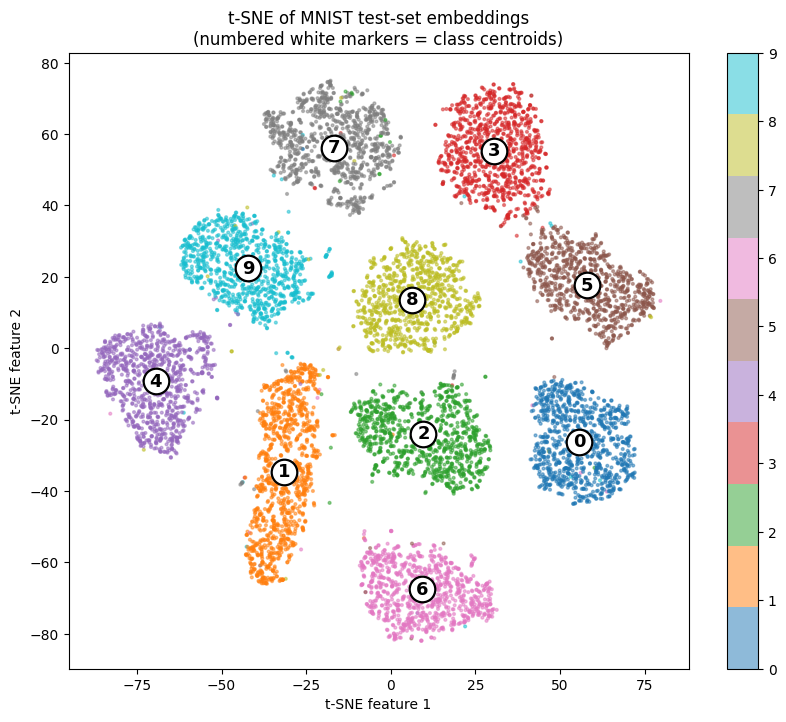

In [12]:
# ---------------------------------------------------------------
# t-SNE visualisation. This cell is provided - do not modify it.
# init, learning_rate and perplexity are pinned explicitly so that the
# layout does not change with the scikit-learn version.
# ---------------------------------------------------------------
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, init="pca",
            learning_rate="auto", random_state=SEED, n_jobs=1)
tsne_results = tsne.fit_transform(test_embeddings)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(tsne_results[:, 0], tsne_results[:, 1],
                      c=test_labels, cmap="tab10", s=4, alpha=0.5)
plt.colorbar(scatter, ticks=range(10))

# Mark the centroid of each class. Questions 4 and 5 are about these markers,
# NOT about individual scattered points.
for c in range(10):
    cx, cy = tsne_results[test_labels == c].mean(axis=0)
    plt.scatter([cx], [cy], marker="o", s=340, facecolor="white",
                edgecolor="black", linewidth=1.6, zorder=5)
    plt.text(cx, cy, str(c), ha="center", va="center",
             fontsize=13, fontweight="bold", zorder=6)

plt.title("t-SNE of MNIST test-set embeddings\n(numbered white markers = class centroids)")
plt.xlabel("t-SNE feature 1")
plt.ylabel("t-SNE feature 2")
plt.show()

#### Question 4

**Among the four options below**, the centroid of which digit's cluster is **closest** to the centroid of
the cluster for digit **7**?

Read this off row 7 of the printed centroid distance matrix. The numbered white markers on the t-SNE plot
show the same centroids. Compare **cluster centroids**, not individual scattered points - every class has
a few stray points sitting inside other clusters, and those are not what this question is about.

1. 0
2. 9
3. 5
4. 6

#### Question 5

**Among the four options below**, the centroid of which digit's cluster is **farthest** from the centroid
of the cluster for digit **6**?

Read this off row 6 of the printed centroid distance matrix. The numbered white markers on the t-SNE plot
show the same centroids. Compare **cluster centroids**, not individual scattered points.

1. 5
2. 0
3. 7
4. 4

### Filter Visualisation

shape of the filters is: (32, 1, 5, 5)


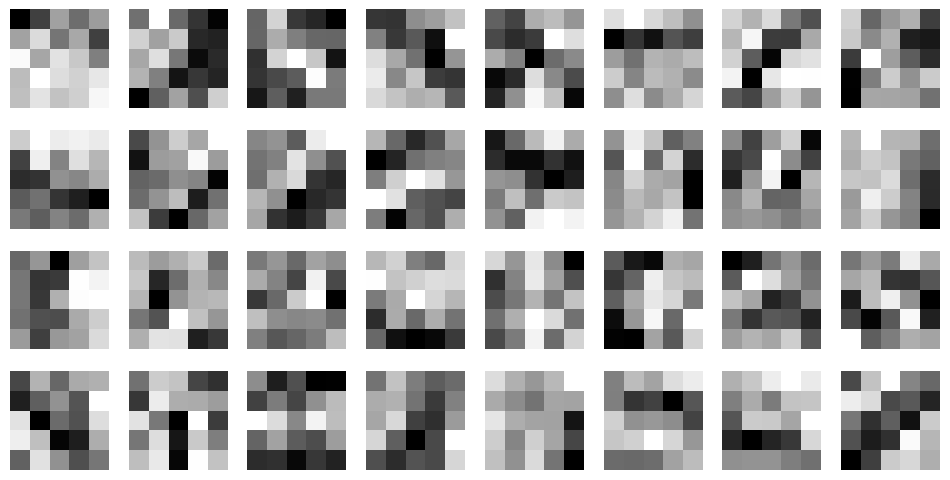

In [13]:
%matplotlib inline
import matplotlib.pyplot as plt

# Get the weights of the first convolutional layer, as a numpy array on the cpu.
#### YOUR CODE STARTS HERE ####
filters = model.conv_block1[0].weight.detach().cpu().numpy()
#### YOUR CODE ENDS HERE ####

print(f"shape of the filters is: {filters.shape}")

# Normalise the filters for better visualisation
min_val = filters.min()
max_val = filters.max()
filters = (filters - min_val) / (max_val - min_val)

# Plot the filters
fig, axes = plt.subplots(4, 8, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    if i < filters.shape[0]:
        # Each filter has shape (out_channels, in_channels, height, width).
        # We take the first in_channel (0) since the input is grayscale.
        ax.imshow(filters[i, 0, :, :], cmap='gray')
        ax.axis('off')
    else:
        ax.axis('off')

plt.show()

#### Question 6

What is the shape of the `filters` array printed above?

1. (32, 16, 5, 5)
2. (32, 1, 5, 5)
3. (16, 32, 5, 5)
4. (16, 1)